In [1]:
# ORB-SLAM3 Python Implementation with MH01 ROS Bag
# This notebook demonstrates how to run ORB-SLAM3 on the EuRoC MH01 dataset using ROS bag playback

import os
import threading
import time
import numpy as np
import cv2
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import rospy
from sensor_msgs.msg import Image
from cv_bridge import CvBridge

import orbslam3


print("ORB-SLAM3 Python Implementation with ROS Bag Playback")
print("=" * 60)


ORB-SLAM3 Python Implementation with ROS Bag Playback


In [ ]:
# Setup ROS bag playback for MH01 dataset
bag_path = "/home/jovyan/ORB_SLAM3/python/MH01.bag"

print("Setting up ROS bag playback...")
print(f"Bag file: {bag_path}")

# Check if bag file exists
if not os.path.exists(bag_path):
    print(f"ERROR: Bag file not found at {bag_path}")
    raise FileNotFoundError(f"Bag file not found: {bag_path}")

print("Bag file found successfully!")

# Initialize ROS node
print("Initializing ROS node...")
rospy.init_node('orbslam3_bag_playback', anonymous=True)

# Initialize CV bridge for image conversion
bridge = CvBridge()

# Global variables for tracking
poses = []
timestamps_processed = []
valid_poses = []
image_count = 0
start_time = None

print("ROS setup complete!")


Setting up ROS bag playback...
Bag file: /home/jovyan/ORB_SLAM3/Examples/ROS/MH01.bag
Bag file found successfully!
Initializing ROS node...
ROS setup complete!


In [3]:
# Initialize ORB-SLAM3 system
print("Initializing ORB-SLAM3 system...")

# Set up paths
vocab_file = "/home/jovyan/ORB_SLAM3/Vocabulary/ORBvoc.txt"
settings_file = "/home/jovyan/ORB_SLAM3/Examples/Monocular/EuRoC.yaml"
sensor_type = orbslam3.Sensor.MONOCULAR

# Initialize the SLAM system
slam = orbslam3.system(vocab_file, settings_file, sensor_type)
slam.initialize()

print("ORB-SLAM3 system initialized successfully!")

# Define image callback function
def image_callback(msg):
    global image_count, start_time, poses, timestamps_processed, valid_poses
    
    try:
        # Convert ROS image message to OpenCV image
        cv_image = bridge.imgmsg_to_cv2(msg, "bgr8")
        
        # Get timestamp from message header
        timestamp = msg.header.stamp.to_sec()
        
        # Initialize start time
        if start_time is None:
            start_time = timestamp
        
        # Process the image through ORB-SLAM3
        pose = slam.process_image_mono(cv_image, timestamp)
        
        # Store pose and timestamp
        poses.append(pose)
        timestamps_processed.append(timestamp)
        valid_poses.append(True)
        
        image_count += 1
        
        # Print progress every 100 images
        if image_count % 100 == 0:
            print(f"Processed image {image_count}")
            print(f"  Timestamp: {timestamp:.3f}s")
            print(f"  Tracking state: {slam.get_tracking_state()}")
            print(f"  Is lost: {slam.is_lost()}")
            
    except Exception as e:
        print(f"Error processing image: {e}")
        valid_poses.append(False)

# Subscribe to the camera topic
print("Subscribing to /cam0/image_raw topic...")
image_sub = rospy.Subscriber('/cam0/image_raw', Image, image_callback)
print("Subscription created successfully!")

Initializing ORB-SLAM3 system...

ORB-SLAM3 Copyright (C) 2017-2020 Carlos Campos, Richard Elvira, Juan J. Gómez, José M.M. Montiel and Juan D. Tardós, University of Zaragoza.
ORB-SLAM2 Copyright (C) 2014-2016 Raúl Mur-Artal, José M.M. Montiel and Juan D. Tardós, University of Zaragoza.
This program comes with ABSOLUTELY NO WARRANTY;
This is free software, and you are welcome to redistribute it
under certain conditions. See LICENSE.txt.

Input sensor was set to: Monocular
SLAM settings: 
	-Camera 1 parameters (Pinhole): [ 458.654 457.296 367.215 248.375 ]
	-Camera 1 distortion parameters: [  -0.283408 0.0739591 0.00019359 1.76187e-05 ]
	-Original image size: [ 752 , 480 ]
	-Current image size: [ 600 , 350 ]
	-Camera 1 parameters after resize: [  365.947 333.445 292.991 181.107 ]
	-Sequence FPS: 20
	-Features per image: 1000
	-ORB scale factor: 1.2
	-ORB number of scales: 8
	-Initial FAST threshold: 20
	-Min FAST threshold: 7


Loading ORB Vocabulary. This could take a while...
Vocabula

In [4]:
# Start ROS bag playback
print("Starting ROS bag playback...")
print("This will play the MH01.bag file and process images through ORB-SLAM3...")

# Start bag playback in a separate thread
def play_bag():
    import subprocess
    try:
        # Play the bag file
        subprocess.run(['rosbag', 'play', bag_path, '-r', '2'], check=True)
        print("Bag playback completed!")
    except subprocess.CalledProcessError as e:
        print(f"Error playing bag: {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")

# Start bag playback in background
bag_thread = threading.Thread(target=play_bag)
bag_thread.daemon = True
bag_thread.start()

# Wait for images to be processed
print("Waiting for images to be processed...")
print("Processing will continue until the bag file finishes playing...")

# Monitor processing
last_count = 0
stall_count = 0
max_stall_count = 50  # Stop if no new images for 50 iterations

while not rospy.is_shutdown():
    if image_count > last_count:
        last_count = image_count
        stall_count = 0
    else:
        stall_count += 1
        
    if stall_count > max_stall_count:
        print("No new images received for a while, stopping...")
        break
        
    time.sleep(0.1)  # Check every 100ms

print(f"\nProcessed {len(poses)} images")
print(f"Valid poses: {sum(valid_poses)}")
print(f"Invalid poses: {len(poses) - sum(valid_poses)}")


Starting ROS bag playback...
This will play the MH01.bag file and process images through ORB-SLAM3...
Waiting for images to be processed...
Processing will continue until the bag file finishes playing...
[ INFO] [1761082126.723266418]: Opening /home/jovyan/ORB_SLAM3/Examples/ROS/MH01.bag

Waiting 0.2 seconds after advertising topics... done.

Hit space to toggle paused, or 's' to step.
First KF:0; Map init KF:03636579.960250   Duration: 1.014044 / 187.749443               5548.07 
New Map created with 271 points
Processed image 100e: 1403636584.752158   Duration: 5.805952 / 187.749443               
  Timestamp: 1403636584.714s
  Tracking state: 2
  Is lost: False
Processed image 200e: 1403636589.752362   Duration: 10.806155 / 187.749443               
  Timestamp: 1403636589.714s
  Tracking state: 2
  Is lost: False
Processed image 300e: 1403636594.752046   Duration: 15.805840 / 187.749443               
  Timestamp: 1403636594.714s
  Tracking state: 2
  Is lost: False
Processed image

In [5]:
# Extract camera trajectory from pose matrices
print("Extracting camera trajectory...")

# Extract camera positions (translation components)
camera_positions = []
valid_timestamps = []

for i, (pose, timestamp, is_valid) in enumerate(zip(poses, timestamps_processed, valid_poses)):
    if is_valid and pose is not None:
        # Extract translation from pose matrix (4x4 homogeneous matrix)
        # The translation is in the last column, first 3 elements
        pose = np.linalg.inv(pose)
        position = pose[:3, 3]  # Extract x, y, z coordinates
        camera_positions.append(position)
        valid_timestamps.append(timestamp)

# Save the camera positions to a file
with open('camera_positions.txt', 'w') as f:
    for timestamp, position in zip(valid_timestamps, camera_positions):
        f.write(f"{timestamp} {position[0]} {position[1]} {position[2]} 0 0 0 1\n")

# Convert to numpy arrays for easier manipulation
camera_positions = np.array(camera_positions)
valid_timestamps = np.array(valid_timestamps)
print(f"Extracted {len(camera_positions)} valid camera positions")

# Calculate trajectory statistics
if len(camera_positions) > 1:
    distances = np.linalg.norm(np.diff(camera_positions, axis=0), axis=1)
    total_distance = np.sum(distances)
    print(f"Total trajectory distance: {total_distance:.3f} meters")
    print(f"Average step size: {np.mean(distances):.3f} meters")


Extracting camera trajectory...
Extracted 3682 valid camera positions
Total trajectory distance: 15.853 meters
Average step size: 0.004 meters


APE w.r.t. translation part (m)
(with Sim(3) Umeyama alignment)

       max	0.067177
      mean	0.018248
    median	0.014079
       min	0.000399
      rmse	0.022193
       sse	1.791802
       std	0.012630

Plot saved to evo_raw
Plot saved to evo_map
Loading evo_map.png...
Loading evo_raw.png...


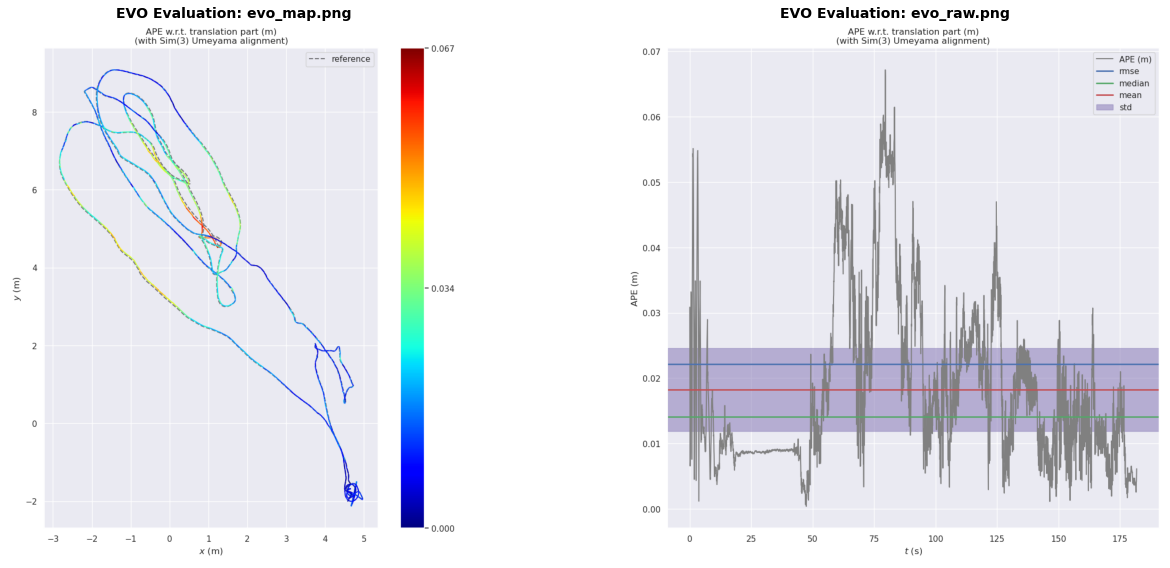

In [6]:
!evo_ape tum ../Datasets/MH01/mav0/gt_tum.txt camera_positions.txt -as -p --save_plot evo --plot_mode xy
plot_files = ['evo_map.png', 'evo_raw.png']
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for i, plot_file in enumerate(plot_files):
    print(f"Loading {plot_file}...")
    img = mpimg.imread(plot_file)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'EVO Evaluation: {plot_file}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Shutdown systems and display final results
print("Shutting down systems...")

# Unsubscribe from topic
if 'image_sub' in globals():
    image_sub.unregister()
    print("Unsubscribed from camera topic")

# Shutdown ORB-SLAM3 system
slam.shutdown()
print("ORB-SLAM3 system shutdown complete")

# Shutdown ROS
rospy.signal_shutdown("Processing complete")
print("ROS shutdown complete")

# Display final results summary
print("\n" + "="*60)
print("ORB-SLAM3 MH01 ROS Bag Processing Summary")
print("="*60)
print(f"Dataset: MH01 (EuRoC) ROS Bag")
print(f"Images processed: {image_count}")
print(f"Valid poses obtained: {sum(valid_poses)}")
print(f"Success rate: {sum(valid_poses)/max(image_count, 1)*100:.1f}%")

if len(camera_positions) > 0:
    print(f"\nTrajectory Statistics:")
    print(f"Trajectory points: {len(camera_positions)}")
    print(f"Total distance: {total_distance:.3f} meters")
    print(f"Average step size: {np.mean(distances):.3f} meters")
    print(f"Time duration: {valid_timestamps[-1] - valid_timestamps[0]:.3f} seconds")

print("\nProcessing completed successfully!")
print("The trajectory has been visualized in the plots above.")


Shutting down systems...
Unsubscribed from camera topic
ORB-SLAM3 system shutdown complete
Shutdown
ROS shutdown complete

ORB-SLAM3 MH01 ROS Bag Processing Summary
Dataset: MH01 (EuRoC) ROS Bag
Images processed: 3682
Valid poses obtained: 3682
Success rate: 100.0%

Trajectory Statistics:
Trajectory points: 3682
Total distance: 15.853 meters
Average step size: 0.004 meters
Time duration: 184.050 seconds

Processing completed successfully!
The trajectory has been visualized in the plots above.
